# Сплайны

# Введение

**Сплайн** – это непрерывная кусочно-заданная функция, каждый фрагмент (сегмент) которой является достаточно простой функцией и строится по контрольным точкам. В большинстве случаев сплайн представляет собой гладкую функцию, а в качестве фрагментов используются алгебраические полиномы.

**Контрольные (опорные) точки** – это точки, в которых известно (точно или приближенно) значение исходной функции (функции, для которой строится сплайн). Контрольные точки используются для задания фрагментов сплайна.

**Контрольная ломаная** – это ломаная (фактически, линейный сплайн), построенная по контрольным точкам.

**Степень сплайна** – максимальная из степеней использованных полиномов.

**Гладкость сплайна** – максимальный порядок непрерывной производной.

**Дефект сплайна** – разность между степенью сплайна и его гладкостью.

Исходя из приведенных определений, непрерывная ломаная есть сплайн степени 1 и дефекта 1, поскольку производная ломаной – это кусочно-постоянная функция (полином степени ноль).

# Задание
<u>**Вариант 2**</u>: Посторить сплайн функции $cos(x^2)$ на $[0,5]$

# Строим таблицу

In [1]:
import math

a = 0
b = 5

#Делаем сетку для первого значения n
n1 = 5
h1 = (b - a) / n1
grid_1_x = list()
grid_1_y = list()

for i in range(n1 + 1):
    grid_1_x.append(i)
    grid_1_y.append(math.cos((i * h1)**2))
#print(grid_1)

#Делаем сетку для второго значения n
n2 = 25
h2 = (b - a) / n2
grid_2_x = list()
grid_2_y = list()
i = a

for i in range(n2 + 1):
    grid_2_x.append(i * h2)
    grid_2_y.append(math.cos((i * h2)**2))

print(f'h_2 = {h2}')
print(grid_1_x)
print(grid_1_y)


h_2 = 0.2
[0, 1, 2, 3, 4, 5]
[1.0, 0.5403023058681398, -0.6536436208636119, -0.9111302618846769, -0.9576594803233847, 0.9912028118634736]


# Вычисляем коэффициенты сплайна

$${\displaystyle c_{i-1}\cdot h_{i}+2\cdot c_{i}\cdot (h_{i}+h_{i+1})+c_{i+1}\cdot h_{i+1}=3\cdot \left({\frac {y_{i+1}-y_{i}}{h_{i+1}}}-{\frac {y_{i}-y_{i-1}}{h_{i}}}\right)}$$

$$\begin{pmatrix}
2(h_1+h_2) & h_2 & & & \\
h_2 & 2(h_2+h_3) & h_3 & & \\
& h_3 & 2(h_3+h_4) & h_4 & \\
& & \ddots & \ddots & \ddots \\
& & & h_{n-2} & 2(h_{n-2}+h_{n-1}) & h_{n-1} \\
& & & & h_{n-1} & 2(h_{n-1}+h_n)
\end{pmatrix} \left(\begin{matrix} c_1 \\ c_2 \\ c_3 \\ ... \\ c_{n-1} \end{matrix}\right) = \left(\begin{matrix} r_1 \\ r_2 \\ r_3 \\ ... \\ r_{n-1} \end{matrix}\right)$$

## Для n = 5

### Создаём матрицу

In [2]:
#>>>-----------------Строим матрицу---------------------->
# n1 = 5
# h1 = 1

import numpy as np
size = n1 - 1

A_1 = np.zeros((size, size))
r_1 = np.zeros(size)

for row in range(size):
    k = row + 2  # k от 2 до n

    A_1[row, row] = 4 * h1  # 2*(h+h) = 4h, т.к. h_{k-1}=h_k=h

    if row + 1 < size:
        A_1[row, row + 1] = h1
        
    if row >= 1:
        A_1[row, row - 1] = h1

    r_1[row] = 3 * ((grid_1_y[k] - grid_1_y[k-1]) - (grid_1_y[k-1] - grid_1_y[k-2])) / h1

In [3]:
print(A_1)
print(r_1)

[[4. 1. 0. 0.]
 [1. 4. 1. 0.]
 [0. 1. 4. 1.]
 [0. 0. 1. 4.]]
[-2.2027447   2.80937786  0.63287227  5.98617453]


### Алгоритм Томпсона – метод прогонки

$$P_1 = \frac{r_1}{2(h_1 + h_2)} \quad Q_1 = - \frac{h_2}{2(h_1 + h_2)}$$

$$P_i = - \frac{h_{i+1}}{2(h_i + h_{i+1}) + h_i P_{i-1}} \quad Q_i = \frac{r_i - h_i Q_{i-1}}{2(h_i + h_{i+1}) + h_i P_{i-1}}$$

$$P_{n-1} = 0 \quad Q_{n-1} = \frac{r_{n-1} - Q_{n-2}}{2(h_n + h_{n-1}) + h_{n-1} P_{n-2}}$$

In [4]:
size = len(r_1)

P = [0] * size
Q = [0] * size
c_inner = [0] * size

#>>>-----------------Прямой ход---------------------->
P[0] = -h1 / (2 * (h1 + h1))
Q[0] = r_1[0] / (2 * (h1 + h1))

for i in range(1, n1 - 1):
    D = h1 * P[i-1] + 4 * h1
    P[i] = -h1 / D
    Q[i] = (r_1[i] - h1 * Q[i-1]) / D

D_last = h1 * P[n1-3] + 4 * h1
P[n1-2] = 0
Q[n1-2] = (r_1[n1-2] - h1 * Q[n1-3]) / D_last

#>>>-----------------Обратный ход---------------------->
c_inner[n1-2] = Q[n1-2]

for i in range(n1-3, -1, -1): # идём от n1-2 вниз до 1 учитывая классичекскую нумерацию списка с 0
    c_inner[i] = P[i] * c_inner[i+1] + Q[i]

print(np.array(c_inner))

c = np.zeros(n1+1)
c[0] = 0.0
c[n1] = 0.0
for i in range(1, n1):
    c[i] = c_inner[i-1]

print(np.array(c))

[-0.80836869  1.03073007 -0.50517371  1.62283706]
[ 0.         -0.80836869  1.03073007 -0.50517371  1.62283706  0.        ]


In [5]:
c_check = np.linalg.solve(A_1, r_1)
print("Прогонка:", np.array(c_inner))
print("np.solve: ", c_check)

Прогонка: [-0.80836869  1.03073007 -0.50517371  1.62283706]
np.solve:  [-0.80836869  1.03073007 -0.50517371  1.62283706]


### Коэффициенты

In [6]:
a_1 = np.zeros(n1+1)
b_1 = np.zeros(n1+1)
c_1 = np.zeros(n1+1)
d_1 = np.zeros(n1+1)

for k in range(1, n1+1):
    a_1[k] = grid_1_y[k-1]
    c_1[k] = c[k-1] / 2
    d_1[k] = (c[k] - c[k-1]) / (6*h1)
    b_1[k] = (grid_1_y[k] - grid_1_y[k-1]) / h1 - h1*(2*c[k-1] + c[k]) / 6

print("c: ", c_1)
print("")
print("a: ", np.array(a_1))
print("")
print("b: ", np.array(b_1))
print("")
print("d: ", np.array(d_1))
print("")


c:  [ 0.          0.         -0.40418435  0.51536503 -0.25258686  0.81141853]

a:  [ 0.          1.          0.54030231 -0.65364362 -0.91113026 -0.95765948]

b:  [ 0.         -0.32496958 -1.09627804 -0.51686771 -0.14861082  1.4079166 ]

d:  [ 0.         -0.13472812  0.30651646 -0.25598396  0.35466846 -0.27047284]



## Для n = 25

### Создаём матрицу

In [7]:
#>>>-----------------Строим матрицу---------------------->
# n1 = 5
# h1 = 1

import numpy as np
size = n2 - 1

A_2 = np.zeros((size, size))
r_2 = np.zeros(size)

for row in range(size):
    k = row + 2  # k от 2 до n

    A_2[row, row] = 4 * h2  # 2*(h+h) = 4h, т.к. h_{k-1}=h_k=h

    if row + 1 < size:
        A_2[row, row + 1] = h2
        
    if row >= 1:
        A_2[row, row - 1] = h2

    r_2[row] = 3 * ((grid_2_y[k] - grid_2_y[k-1]) - (grid_2_y[k-1] - grid_2_y[k-2])) / h2

In [8]:
len(grid_2_y)
#print(A_2)
#print(r_2)

26

### Алгоритм Томпсона – метод прогонки

In [9]:
size = len(r_2)

P = [0] * size
Q = [0] * size
c_inner = [0] * size

#>>>-----------------Прямой ход---------------------->
P[0] = -h2 / (2 * (h2 + h2))
Q[0] = r_2[0] / (2 * (h2 + h2))

for i in range(1, n2 - 1):
    D = h2 * P[i-1] + 4 * h2
    P[i] = -h2 / D
    Q[i] = (r_2[i] - h2 * Q[i-1]) / D

D_last = h2 * P[n2-3] + 4 * h2
P[n2-2] = 0
Q[n2-2] = (r_2[n2-2] - h2 * Q[n2-3]) / D_last

#>>>-----------------Обратный ход---------------------->
c_inner[n2-2] = Q[n2-2]

for i in range(n2-3, -1, -1): # идём от n1-2 вниз до 1 учитывая классичекскую нумерацию списка с 0
    c_inner[i] = P[i] * c_inner[i+1] + Q[i]

#print(np.array(c_inner))

c = np.zeros(n2+1)
c[0] = 0.0
c[n2] = 0.0
for i in range(1, n2):
    c[i] = c_inner[i-1]

#print(np.array(c))

In [10]:
c_check = np.linalg.solve(A_2, r_2)
print("Прогонка:", np.array(c_inner))
print("np.solve: ", c_check)

Прогонка: [ -0.09465892  -0.45933405  -1.01982759  -1.64665105  -1.99299719
  -1.48774606   0.44421572   3.74126777   6.83300465   6.50856929
   0.08699006 -10.00213925 -13.83377152  -1.91598085  17.7003482
  17.40470625 -12.67812208 -29.09559698   8.28492807  38.12948898
 -13.01326357 -45.47655128  39.99585687  14.64433153]
np.solve:  [ -0.09465892  -0.45933405  -1.01982759  -1.64665105  -1.99299719
  -1.48774606   0.44421572   3.74126777   6.83300465   6.50856929
   0.08699006 -10.00213925 -13.83377152  -1.91598085  17.7003482
  17.40470625 -12.67812208 -29.09559698   8.28492807  38.12948898
 -13.01326357 -45.47655128  39.99585687  14.64433153]


### Коэффициенты

In [11]:
a_2 = np.zeros(n2+1)
b_2 = np.zeros(n2+1)
c_2 = np.zeros(n2+1)
d_2 = np.zeros(n2+1)

for k in range(1, n2+1):
    a_2[k] = grid_2_y[k-1]
    c_2[k] = c[k-1] / 2
    d_2[k] = (c[k] - c[k-1]) / (6*h2)
    b_2[k] = (grid_2_y[k] - grid_2_y[k-1]) / h2 - h2*(2*c[k-1] + c[k]) / 6

print("c: ", c_2)
print("")
print("a: ", np.array(a_2))
print("")
print("b: ", np.array(b_2))
print("")
print("d: ", np.array(d_2))
print("")

c:  [  0.           0.          -0.04732946  -0.22966703  -0.50991379
  -0.82332552  -0.9964986   -0.74387303   0.22210786   1.87063389
   3.41650232   3.25428464   0.04349503  -5.00106962  -6.91688576
  -0.95799043   8.8501741    8.70235313  -6.33906104 -14.54779849
   4.14246403  19.06474449  -6.50663179 -22.73827564  19.99792844
   7.32216577]

a:  [ 0.          1.          0.99920011  0.98722728  0.93589682  0.80209576
  0.54030231  0.13042371 -0.37945176 -0.83558878 -0.9951619  -0.65364362
  0.12726495  0.86623206  0.88846133  0.01398118 -0.91113026 -0.68570679
  0.53493069  0.92352312 -0.29822554 -0.95765948  0.35343485  0.87252763
 -0.67402775 -0.49856702]

b:  [ 0.00000000e+00 -8.44169268e-04 -3.82423864e-02 -1.92035775e-01
 -5.46128455e-01 -1.13275728e+00 -1.86693497e+00 -2.46500149e+00
 -2.43500837e+00 -1.27505030e+00  1.03510546e+00  3.46773858e+00
  4.02244086e+00  1.23908133e+00 -3.38628329e+00 -5.08783675e+00
 -6.33062744e-01  5.36547774e+00  3.75802352e+00 -4.44520112e+0

# Значений сплайна и заданной функции на серединах отрезков

## Для n = 5

In [12]:
print("Значения сплайна и функции в серединах отрезков:")
print(f"{'i':<3}{'x_ci':<10}{'S(x_ci)':<12}{'f(x_ci)':<12}{'|разница|':<12}")

for i in range(1, n1+1):
    x_ci = a + (i - 0.5) * h1
    dx = x_ci - grid_1_x[i-1]
    S_val = a_1[i] + b_1[i]*dx + c_1[i]*dx**2 + d_1[i]*dx**3
    f_val = math.cos(x_ci**2)
    diff = abs(S_val - f_val)
    print(f"{i:<3}{x_ci:<10.4f}{S_val:<12.4f}{f_val:<12.4f}{diff:<12.4e}")

Значения сплайна и функции в серединах отрезков:
i  x_ci      S(x_ci)     f(x_ci)     |разница|   
1  0.5000    0.8207      0.9689      1.4824e-01  
2  1.5000    -0.0706     -0.6282     5.5761e-01  
3  2.5000    -0.8152     0.9994      1.8147e+00  
4  3.5000    -1.0042     0.9504      1.9546e+00  
5  4.5000    -0.0847     0.1695      2.5419e-01  


## Для n = 25

In [13]:
print("Значения сплайна и функции в серединах отрезков:")
print(f"{'i':<3}{'x_ci':<10}{'S(x_ci)':<12}{'f(x_ci)':<12}{'|разница|':<12}")

for i in range(1, n1+1):
    x_ci = a + (i - 0.5) * h2
    dx = x_ci - grid_2_x[i-1]
    S_val = a_2[i] + b_2[i]*dx + c_2[i]*dx**2 + d_2[i]*dx**3
    f_val = math.cos(x_ci**2)
    diff = abs(S_val - f_val)
    print(f"{i:<3}{x_ci:<10.4f}{S_val:<12.4f}{f_val:<12.4f}{diff:<12.4e}")

Значения сплайна и функции в серединах отрезков:
i  x_ci      S(x_ci)     f(x_ci)     |разница|   
1  0.1000    0.9998      1.0000      1.1330e-04  
2  0.3000    0.9946      0.9960      1.3541e-03  
3  0.5000    0.9653      0.9689      3.6525e-03  
4  0.7000    0.8757      0.8823      6.6704e-03  
5  0.9000    0.6803      0.6895      9.2003e-03  


# Таблица

In [14]:
import pandas as pd

# n=5: контрольные точки и значения
rows = []
for i in range(1, n1+1):
    x_ci = a + (i - 0.5) * h1
    f_ci = math.cos(x_ci**2)
    s5 = a_1[i] + b_1[i]*h1/2 + c_1[i]*h1**2/4 + d_1[i]*h1**3/8
    rows.append({"x_ci": x_ci, "f_ci": f_ci, "s_n5": s5})

# n=25: соответствующие индексы i для тех же x_ci
idx25 = [3 + 5*(j-1) for j in range(1, 6)]  # [3, 8, 13, 18, 23]
for row, i25 in zip(rows, idx25):
    s25 = a_2[i25] + b_2[i25]*h2/2 + c_2[i25]*h2**2/4 + d_2[i25]*h2**3/8
    row["s_n25"] = s25

df = pd.DataFrame(rows)
df.columns = ["x_ci", "f(x_ci)", "s(x), n=5", "s(x), n=25"]
print(df.to_string(index=False))

 x_ci   f(x_ci)  s(x), n=5  s(x), n=25
  0.5  0.968912   0.820674    0.965260
  1.5 -0.628174  -0.070568   -0.617984
  2.5  0.999449  -0.815234    0.936936
  3.5  0.950371  -1.004249    0.833661
  4.5  0.169530  -0.084656    0.112952


# Графики

## Для n = 5

In [15]:
import sympy as sm

x = sm.Symbol('x')

sp_len = len(grid_1_x)  # количество узлов

S = sm.Piecewise(*[
    (a_1[k] 
     + b_1[k]*(x - grid_1_x[k-1]) 
     + c_1[k]*(x - grid_1_x[k-1])**2 
     + d_1[k]*(x - grid_1_x[k-1])**3,
     (x >= grid_1_x[k-1]) & (x <= grid_1_x[k]))
    for k in range(1, sp_len)
], (sm.nan, True))

S_x = sm.lambdify(x, S, modules=['numpy'])

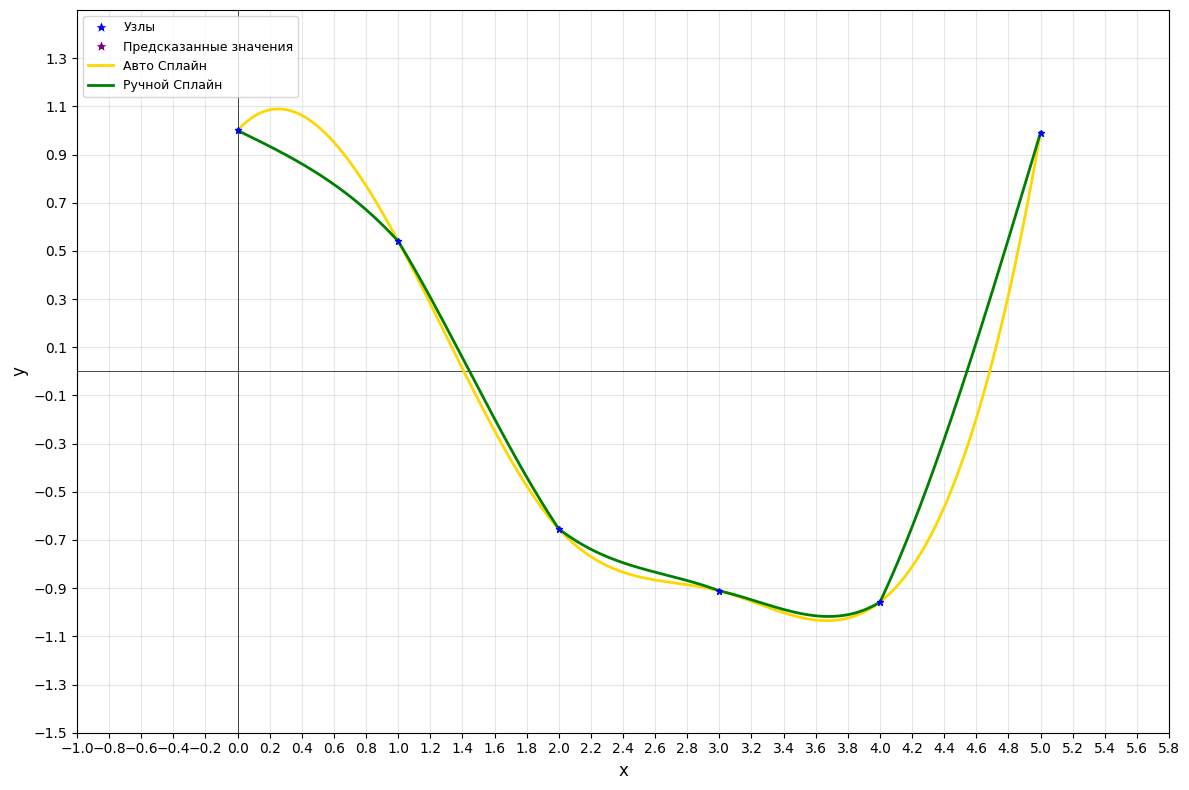

In [16]:
import matplotlib.pyplot as plt
import numpy as np

#>>>-----------------автосплайн---------------------->
from scipy.interpolate import CubicSpline
S_x_true = CubicSpline(grid_1_x, grid_1_y)


#x_points = grid_1_x_extra
#y_points = grid_1_x_extra

#>>>-----------------Задаём диапазон значений и функции---------------------->
x_plot = np.linspace(0, 5, 800)
y_plot_true = S_x_true(x_plot)
y_plot = S_x(x_plot)

#>>>-----------------Задаем фигуру---------------------->
fig, ax = plt.subplots(figsize=(12, 8))

#>>>-----------------Настройка графика---------------------->
ax.set_xlim(-0.2, 5.2)
ax.set_ylim(-1.5, 1.5)
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.grid(True, alpha=0.3)  # Включаем сетку (alpha - прозрачность)
ax.axhline(y=0, color='black', linewidth=0.5)
ax.axvline(x=0, color='black', linewidth=0.5) 
ax.set_xticks(np.arange(-1, 6, 0.2))
ax.set_yticks(np.arange(-1.5, 1.5, 0.2))

#>>>-----------------Строим графики, ставим точки---------------------->
ax.plot(x_plot, y_plot_true, color='gold', linewidth=2)
ax.plot(x_plot, y_plot, color='green', linewidth=2)

#for i in range(0, len()):
#    ax.plot(x_points[i], y_points[i], '*', markersize=5, color='purple')
    
for i in range(0, len(grid_1_x)):
    ax.plot(grid_1_x[i], grid_1_y[i], '*', markersize=5, color='blue')

#>>>-----------------Легенда---------------------->
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='*', color='w', markerfacecolor='blue', markersize=10, label='Узлы'),
    Line2D([0], [0], marker='*', color='w', markerfacecolor='purple', markersize=10, label='Предсказанные значения'),
    Line2D([0], [0], color='gold', linewidth=2, label='Авто Сплайн'),
    Line2D([0], [0], color='green', linewidth=2, label='Ручной Сплайн'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

## Для n = 25

In [17]:
import sympy as sm

x = sm.Symbol('x')

sp_len = len(grid_2_x)  # количество узлов

S = sm.Piecewise(*[
    (a_2[k] 
     + b_2[k]*(x - grid_2_x[k-1]) 
     + c_2[k]*(x - grid_2_x[k-1])**2 
     + d_2[k]*(x - grid_2_x[k-1])**3,
     (x >= grid_2_x[k-1]) & (x <= grid_2_x[k]))
    for k in range(1, sp_len)
], (sm.nan, True))

S_x_2 = sm.lambdify(x, S, modules=['numpy'])

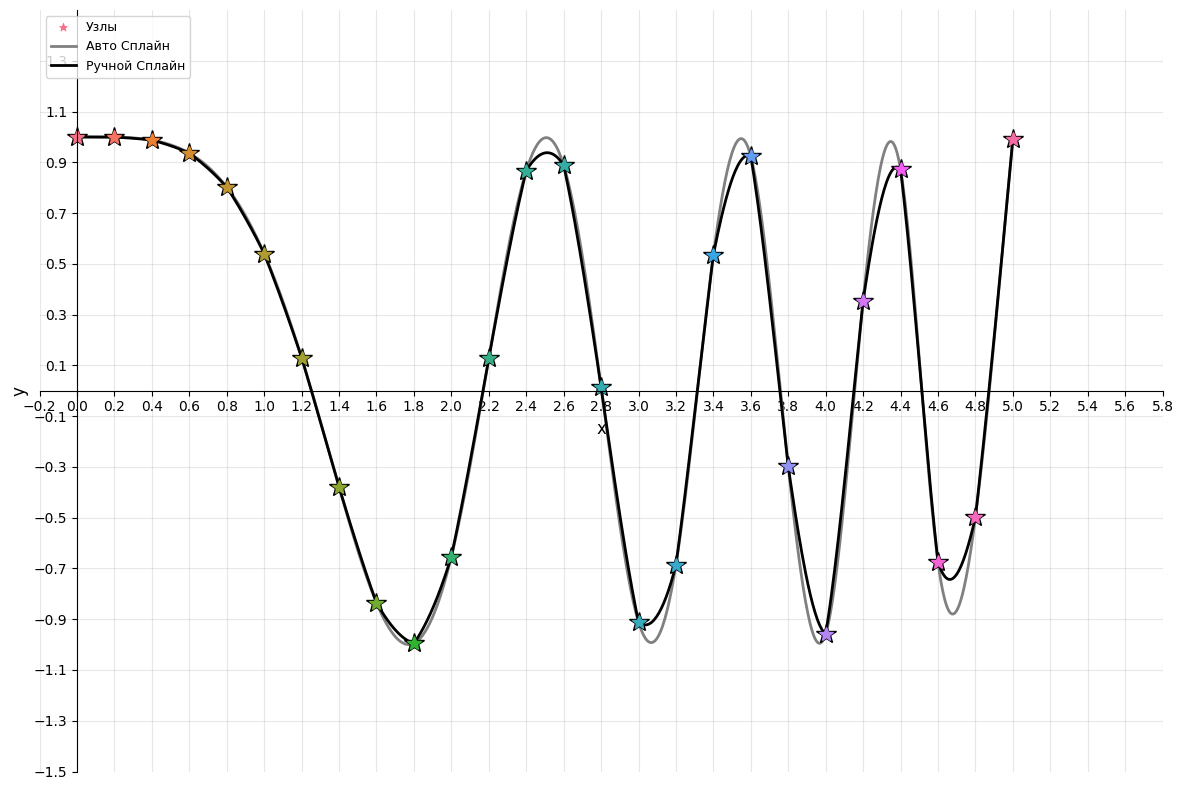

In [35]:
import matplotlib.pyplot as plt
import numpy as np

#>>>-----------------Радужные звёзды!---------------------->
import seaborn as sns

colors = sns.color_palette("husl", 26)


#>>>-----------------автосплайн---------------------->
from scipy.interpolate import CubicSpline
S_x_true = CubicSpline(grid_2_x, grid_2_y)


#x_points = grid_1_x_extra
#y_points = grid_1_x_extra

#>>>-----------------Задаём диапазон значений и функции---------------------->
x_plot = np.linspace(0, 5, 800)
y_plot_true = S_x_true(x_plot)
y_plot = S_x_2(x_plot)

#>>>-----------------Задаем фигуру---------------------->
fig, ax = plt.subplots(figsize=(12, 8))

#>>>-----------------Настройка графика---------------------->
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')

ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')

ax.set_xlim(-0.2, 5.2)
ax.set_ylim(-1.5, 1.5)
ax.set_xlabel('x', fontsize=12)  # Подпись справа на оси X
ax.set_ylabel('y', fontsize=12)  # Подпись сверху на оси Y
ax.grid(True, alpha=0.3)  # Включаем сетку (alpha - прозрачность)
ax.axhline(y=0, color='black', linewidth=0.5)
ax.axvline(x=0, color='black', linewidth=0.5) 
ax.set_xticks(np.arange(-0.2, 6, 0.2))
ax.set_yticks(np.arange(-1.5, 1.5, 0.2))

#>>>-----------------Строим графики, ставим точки---------------------->
ax.plot(x_plot, y_plot_true, color='gray', linewidth=2)
ax.plot(x_plot, y_plot, color='black', linewidth=2)

#for i in range(0, len()):
#    ax.plot(x_points[i], y_points[i], '*', markersize=5, color='purple')
    
for i in range(0, len(grid_2_x)):
    ax.plot(grid_2_x[i], grid_2_y[i], '*', markersize=15, color='black')
    ax.plot(grid_2_x[i], grid_2_y[i], '*', markersize=10, color=colors[i])

#>>>-----------------Легенда---------------------->
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='*', color='w', markerfacecolor=colors[0], markersize=10, label='Узлы'),
    #Line2D([0], [0], marker='*', color='w', markerfacecolor='purple', markersize=10, label='Предсказанные значения'),
    Line2D([0], [0], color='gray', linewidth=2, label='Авто Сплайн'),
    Line2D([0], [0], color='black', linewidth=2, label='Ручной Сплайн'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()